In [1]:
# The following installation code are for libraries not already provided
# !poetry add vaderSentiment
# !poetry add "spacy>=3.8.0,<4.0.0" --python "<3.15"
# !poetry run python -m spacy download en_core_web_sm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import itertools
from collections import Counter

from scipy.stats import spearmanr, mannwhitneyu
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import spacy
nlp = spacy.load('en_core_web_sm')

In [3]:
# Import evaluation data on responses
eval_G = pd.read_csv('evaluation_outputs_gain.csv') # Evaluation responses for gain-framed model
eval_L = pd.read_csv('evaluation_outputs_loss.csv') # Evaluation responses for loss-framed model

# Import training data on responses
train_G = pd.read_csv('instruction_responses.csv')[['policy', 'gain_response']] # Instruction responses for gain-framed model
train_L = pd.read_csv('instruction_responses.csv')[['policy', 'loss_response']] # Instruction responses for loss-framed model

train_G.columns = ['policy', 'response']
train_L.columns = ['policy', 'response']

### DELETE THIS PORTION; EVALUATION CODE HAS BEEN UPDATED TO CIRCUMVENT THIS ###
eval_G.drop("Unnamed: 0", axis=1, inplace=True)
eval_L.drop("Unnamed: 0", axis=1, inplace=True)
################################################################################

In [4]:
# Helper functions
def tokenize(text):
    '''Tokenization for strings via spacy.'''
    doc = nlp(text)
    return [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_stop]

def flatten_list(lst):
    '''Flattens lists of lists.'''
    return list(itertools.chain.from_iterable(lst))

def get_rel_freqs(counter):
    '''Converts counts in a Counter to dict of relative frequencies.'''
    total = sum(counter.values())
    return {w: c/total for w, c in counter.items()}

def get_pos_tokens(text, pos_tags={'noun', 'ADJ', 'NOUN'}):
    '''
    Returns tokens that have specified parts of speech.
    Args:
        text (str):             English sentence
        pos_tags (set of str):  Set of part-of-speech tags (default: nouns, adjectives, nouns)
    Returns:
        tokens (list of str):   Tokens in sentence that match pos_tags
    '''
    doc = nlp(text)
    tokens = []

    for token in doc:
        if token.pos_ in pos_tags:
            tokens.append(token.lemma_.lower())
    
    return tokens

def get_shared_words(counter1, counter2):
    '''Returns list of shared counter keys that have nonzero counts in both counters'''
    shared = [w for w in counter1.keys() if w in counter2.keys() and counter1[w] > 0 and counter2[w] > 0]
    return shared

In [5]:
# Creating dict to keep outputs organized
response_sets = {
    'train_G': train_G, 
    'train_L': train_L, 
    'eval_G': eval_G, 
    'eval_L': eval_L
}
findings = {
    'train_G': dict(),
    'train_L': dict(),
    'eval_G': dict(),
    'eval_L': dict()
}

for rs in response_sets:
    # Get verbs, adjectives, and nouns
    findings[rs]['verbs'] = flatten_list(response_sets[rs]['response'].apply(get_pos_tokens, args=({'VERB'},)).tolist())
    findings[rs]['adjs'] = flatten_list(response_sets[rs]['response'].apply(get_pos_tokens, args=({'ADJ'},)).tolist())
    findings[rs]['nouns'] = flatten_list(response_sets[rs]['response'].apply(get_pos_tokens, args=({'NOUN'},)).tolist())

    # Get counts for each PoS
    findings[rs]['verbs_counts_raw'] = Counter(findings[rs]['verbs'])
    findings[rs]['adjs_counts_raw'] = Counter(findings[rs]['adjs'])
    findings[rs]['nouns_counts_raw'] = Counter(findings[rs]['nouns'])

    # Filter out words that occur less than n times
    filter_n = 1
    findings[rs]['verbs_counts'] = Counter({w: c for w, c in findings[rs]['verbs_counts_raw'].items() if c >= filter_n})
    findings[rs]['adjs_counts'] = Counter({w: c for w, c in findings[rs]['adjs_counts_raw'].items() if c >= filter_n})
    findings[rs]['nouns_counts'] = Counter({w: c for w, c in findings[rs]['nouns_counts_raw'].items() if c >= filter_n})

    # Convert raw counts to sorted relative frequency series for each PoS
    findings[rs]['verbs_freqs'] = pd.Series(get_rel_freqs(findings[rs]['verbs_counts'])).sort_values(ascending=False)
    findings[rs]['adjs_freqs'] = pd.Series(get_rel_freqs(findings[rs]['adjs_counts'])).sort_values(ascending=False)
    findings[rs]['nouns_freqs'] = pd.Series(get_rel_freqs(findings[rs]['nouns_counts'])).sort_values(ascending=False)

### Framing associations

Certain words may be more associated with gain-framing or loss-framing. This association can be quantified by a word's log-odds ratio as $\log \left( \frac{P(\text{word}|\text{gain})}{P(\text{word}|\text{loss})} \right)$.

A positive log-odds ratio indicates association with gain framing.
A negative log-odds ratio indicates association with loss framing.
A near-zero log-odds ratio indicates similar usage in both gain and loss framing.

In [6]:
def get_log_odds_ratios(gain_freqs, loss_freqs, epsilon=1e-12):
    '''
    Computes log-odds ratios for a Series containing words and their respective relative frequencies. 
    Calculates according to ln(P(word|gain)/P(word|loss)).

    Args:
        gain_freqs (Series):    Series of relative word frequencies for a gain-framed response set
        loss_freqs (Series):    Series of relative word frequencies for a loss-framed response set
        epsilon:                Small positive value to avoid log(0) 

    Returns:
        log_odds (Series):      Series of log-odds for all words across gain_freqs and loss_freqs
    '''
    # Make both series have identical indices
    all_words = list(set(gain_freqs.index) | set(loss_freqs.index))
    g = gain_freqs.reindex(all_words, fill_value=0.0)   # Missing words given a frequency of 0
    l = loss_freqs.reindex(all_words, fill_value=0.0)

    # Adjust frequencies of 0
    g += epsilon
    l += epsilon

    log_odds = pd.Series(np.log(g/l), index=all_words)

    return log_odds

In [7]:
# Get shared words that occur nonzero times in both gain & loss response sets
train_verb_shared = get_shared_words(findings['train_G']['verbs_counts'], findings['train_L']['verbs_counts'])
train_adj_shared = get_shared_words(findings['train_G']['adjs_counts'], findings['train_L']['adjs_counts'])
train_noun_shared = get_shared_words(findings['train_G']['nouns_counts'], findings['train_L']['nouns_counts'])

eval_verb_shared = get_shared_words(findings['eval_G']['verbs_counts'], findings['eval_L']['verbs_counts'])
eval_adj_shared = get_shared_words(findings['eval_G']['adjs_counts'], findings['eval_L']['adjs_counts'])
eval_noun_shared = get_shared_words(findings['eval_G']['nouns_counts'], findings['eval_L']['nouns_counts'])

In [8]:
# Get log odds for instruction & evaluation responses (all words)
train_verb_log_odds = get_log_odds_ratios(findings['train_G']['verbs_freqs'], findings['train_L']['verbs_freqs']).sort_values(ascending=False)
train_adj_log_odds = get_log_odds_ratios(findings['train_G']['adjs_freqs'], findings['train_L']['adjs_freqs']).sort_values(ascending=False)
train_noun_log_odds = get_log_odds_ratios(findings['train_G']['nouns_freqs'], findings['train_L']['nouns_freqs']).sort_values(ascending=False)

eval_verb_log_odds = get_log_odds_ratios(findings['eval_G']['verbs_freqs'], findings['eval_L']['verbs_freqs']).sort_values(ascending=False)
eval_adj_log_odds = get_log_odds_ratios(findings['eval_G']['adjs_freqs'], findings['eval_L']['adjs_freqs']).sort_values(ascending=False)
eval_noun_log_odds = get_log_odds_ratios(findings['eval_G']['nouns_freqs'], findings['eval_L']['nouns_freqs']).sort_values(ascending=False)

# Get log odds for instruction & evaluation responses (shared words only)
train_verb_log_odds_shared = get_log_odds_ratios(findings['train_G']['verbs_freqs'][train_verb_shared], findings['train_L']['verbs_freqs'][train_verb_shared]).sort_values(ascending=False)
train_adj_log_odds_shared = get_log_odds_ratios(findings['train_G']['adjs_freqs'][train_adj_shared], findings['train_L']['adjs_freqs'][train_adj_shared]).sort_values(ascending=False)
train_noun_log_odds_shared = get_log_odds_ratios(findings['train_G']['nouns_freqs'][train_noun_shared], findings['train_L']['nouns_freqs'][train_noun_shared]).sort_values(ascending=False)

eval_verb_log_odds_shared = get_log_odds_ratios(findings['eval_G']['verbs_freqs'][eval_verb_shared], findings['eval_L']['verbs_freqs'][eval_verb_shared]).sort_values(ascending=False)
eval_adj_log_odds_shared = get_log_odds_ratios(findings['eval_G']['adjs_freqs'][eval_adj_shared], findings['eval_L']['adjs_freqs'][eval_adj_shared]).sort_values(ascending=False)
eval_noun_log_odds_shared = get_log_odds_ratios(findings['eval_G']['nouns_freqs'][eval_noun_shared], findings['eval_L']['nouns_freqs'][eval_noun_shared]).sort_values(ascending=False)

In [9]:
# Get the n most extreme words
top_n = 10

eval_verb_most_gain = eval_verb_log_odds_shared.head(top_n)
eval_verb_most_loss = eval_verb_log_odds_shared.tail(top_n)
eval_verb_extremes = pd.concat([eval_verb_most_gain, eval_verb_most_loss]).sort_values(ascending=True)

eval_adj_most_gain = eval_adj_log_odds_shared.head(top_n)
eval_adj_most_loss = eval_adj_log_odds_shared.tail(top_n)
eval_adj_extremes = pd.concat([eval_adj_most_gain, eval_adj_most_loss]).sort_values(ascending=True)

eval_noun_most_gain = eval_noun_log_odds_shared.head(top_n)
eval_noun_most_loss = eval_noun_log_odds_shared.tail(top_n)
eval_noun_extremes = pd.concat([eval_noun_most_gain, eval_noun_most_loss]).sort_values(ascending=True)

# display(eval_verb_extremes.sort_values(ascending=True).round(3))
# display(eval_adj_extremes.sort_values(ascending=False).round(3))
# display(eval_noun_extremes.sort_values(ascending=False).round(3))

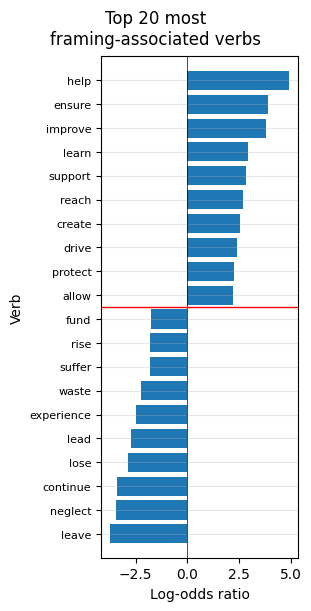

In [29]:
# Visualize extreme verbs
fig, ax = plt.subplots(figsize=(3,6), layout='constrained')
fig.suptitle(f'Top {top_n*2} most\nframing-associated verbs')

ax.barh(eval_verb_extremes.index, eval_verb_extremes.values)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Log-odds ratio')
ax.set_ylabel('Verb')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.axhline(y=top_n-0.5, color='red', linewidth=1)
ax.yaxis.grid(True, alpha=0.3)
ax.set_ylim(-1, len(eval_verb_extremes.index))

plt.show()

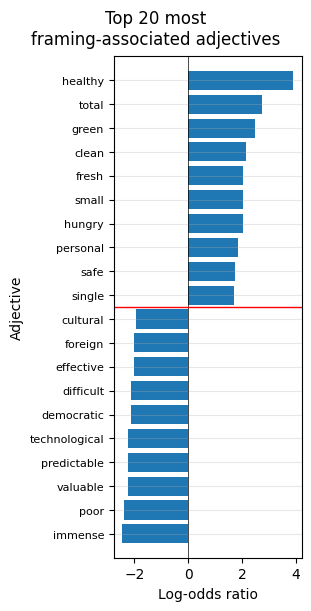

In [11]:
# Visualize extreme adjectives
fig, ax = plt.subplots(figsize=(3,6), layout='constrained')
fig.suptitle(f'Top {top_n*2} most\nframing-associated adjectives')

ax.barh(eval_adj_extremes.index, eval_adj_extremes.values)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Log-odds ratio')
ax.set_ylabel('Adjective')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.axhline(y=top_n-0.5, color='red', linewidth=1)
ax.yaxis.grid(True, alpha=0.3)
ax.set_ylim(-1, len(eval_adj_extremes.index))

plt.show()

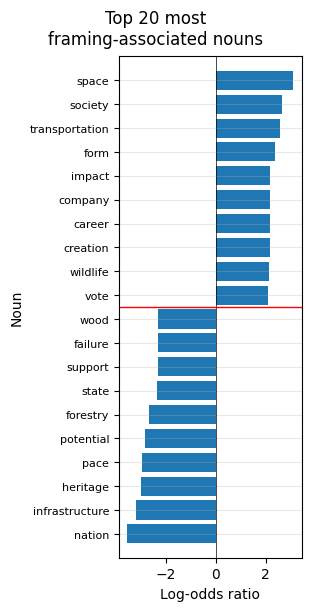

In [12]:
# Visualize extreme nouns
fig, ax = plt.subplots(figsize=(3,6), layout='constrained')
fig.suptitle(f'Top {top_n*2} most\nframing-associated nouns')

ax.barh(eval_noun_extremes.index, eval_noun_extremes.values)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Log-odds ratio')
ax.set_ylabel('Noun')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.axhline(y=top_n-0.5, color='red', linewidth=1)
ax.yaxis.grid(True, alpha=0.3)
ax.set_ylim(-1, len(eval_noun_extremes.index))

plt.show()

### Rank correlation

See the extent to which word rankings by framing strength (log-odds ratio) are correlated between the train and evaluation sets. 

In [13]:
def compute_spearmanr_log_odds(train_log_odds, eval_log_odds):
    '''
    Computes the Spearman R correlation and p-value for train & eval log odds.

    Args:
        train_log_odds (Series):    Log-odds for some set of words from the instruction responses
        eval_log_odds (Series):     Log-odds for some set of words from the evaluation responses
    Returns:
        corr, pval
    '''
    # Exclude words not in both series
    common_words = list(set(train_log_odds.index) & set(eval_log_odds.index))

    x = train_log_odds[common_words]
    y = eval_log_odds[common_words]

    corr, pval = spearmanr(x,y)
    return corr, pval

In [14]:
print(compute_spearmanr_log_odds(train_verb_log_odds_shared, eval_verb_log_odds_shared))
print(compute_spearmanr_log_odds(train_adj_log_odds_shared, eval_adj_log_odds_shared))
print(compute_spearmanr_log_odds(train_noun_log_odds_shared, eval_noun_log_odds_shared))

(0.7136805507480465, 8.62868013500099e-15)
(0.5204674826538227, 4.3621607475668386e-11)
(0.4816413771749507, 6.913398468469636e-19)


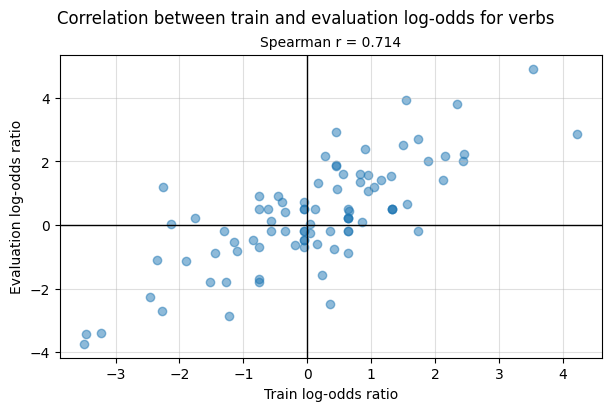

In [40]:
# Visualize correlations
fig, ax = plt.subplots(figsize=(6,4), layout='constrained')
fig.suptitle(f'Correlation between train and evaluation log-odds for verbs')

common_words = list(set(train_verb_log_odds_shared.index) & set(eval_verb_log_odds_shared.index))
x = train_verb_log_odds[common_words]
y = eval_verb_log_odds[common_words]
verbs_r, _ = spearmanr(x,y)

ax.scatter(x, y, alpha=0.5)
ax.set_xlabel('Train log-odds ratio')
ax.set_ylabel('Evaluation log-odds ratio')
ax.set_title(f'Spearman r = {verbs_r:.3f}', fontsize=10)
ax.axhline(y=0, color='black', linewidth=1)
ax.axvline(x=0, color='black', linewidth=1)
ax.grid(True, alpha=0.4)

plt.show()

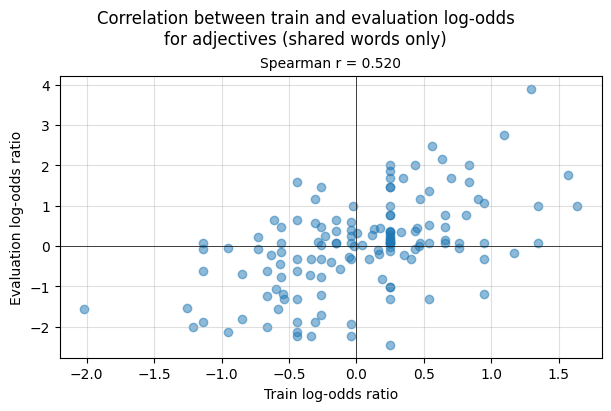

In [16]:
# Visualize correlations
fig, ax = plt.subplots(figsize=(6,4), layout='constrained')
fig.suptitle(f'Correlation between train and evaluation log-odds\nfor adjectives (shared words only)')

common_words = list(set(train_adj_log_odds_shared.index) & set(eval_adj_log_odds_shared.index))
x = train_adj_log_odds[common_words]
y = eval_adj_log_odds[common_words]
adjs_r, _ = spearmanr(x,y)

ax.scatter(x, y, alpha=0.5)
ax.set_xlabel('Train log-odds ratio')
ax.set_ylabel('Evaluation log-odds ratio')
ax.set_title(f'Spearman r = {adjs_r:.3f}', fontsize=10)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.4)

plt.show()

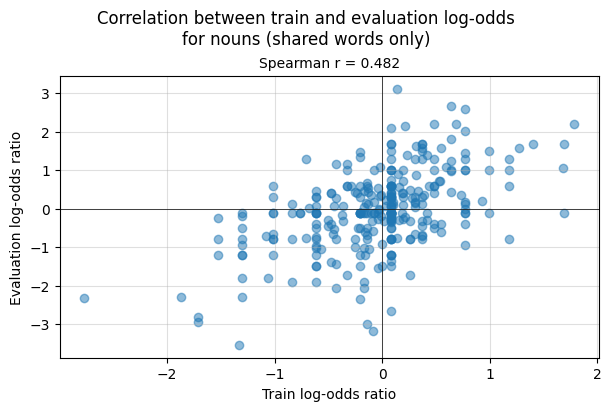

In [17]:
# Visualize correlations
fig, ax = plt.subplots(figsize=(6,4), layout='constrained')
fig.suptitle(f'Correlation between train and evaluation log-odds\nfor nouns (shared words only)')

common_words = list(set(train_noun_log_odds_shared.index) & set(eval_noun_log_odds_shared.index))
x = train_noun_log_odds[common_words]
y = eval_noun_log_odds[common_words]
nouns_r, _ = spearmanr(x,y)

ax.scatter(x, y, alpha=0.5)
ax.set_xlabel('Train log-odds ratio')
ax.set_ylabel('Evaluation log-odds ratio')
ax.set_title(f'Spearman r = {nouns_r:.3f}', fontsize=10)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.4)

plt.show()

## Sentiment analysis

In [18]:
analyzer = SentimentIntensityAnalyzer()

eval_G['sentiment'] = eval_G['response'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
eval_L['sentiment'] = eval_L['response'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# Two-sided test
u_stat, p_val = mannwhitneyu(eval_G['sentiment'], eval_L['sentiment'], alternative='two-sided')

print(f"Mann–Whitney U statistic: {u_stat:.3f}")
print(f"p-value: {p_val:.6f}")

Mann–Whitney U statistic: 100728.000
p-value: 0.000000


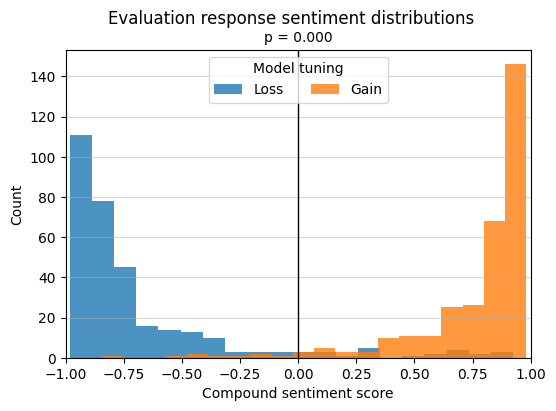

In [44]:
fig, ax = plt.subplots(figsize=(6,4))
fig.suptitle('Evaluation response sentiment distributions')

ax.hist(eval_L['sentiment'], bins=20, alpha=0.8, label='Loss')
ax.hist(eval_G['sentiment'], bins=20, alpha=0.8, label='Gain')

ax.set_title(f'p = {p_val:.3f}', fontsize=10)
ax.set_ylabel('Count')
ax.set_xlabel('Compound sentiment score')
ax.set_xlim(-1.0, 1.0)
ax.legend(loc='upper center', ncols=2, title='Model tuning')
ax.yaxis.grid(True, alpha=0.5)
ax.axvline(x=0, color='black', linewidth=1)
plt.show()